In [1]:
# stuff that he copies into every jupyter notebook always
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
# scalar value function that takes a single scalar x, and returns a single scalar y
def f(x):
    return 3*x**2 -4*x + 5 # parabola

In [3]:
f(3)

20

In [4]:
# set of scalar values that we can feed into the f(x):
xs = np.arange(-5, 5, 0.25) # array of values from -5 to 5, increment by 0.25
ys = f(xs)
ys

array([100.    ,  91.6875,  83.75  ,  76.1875,  69.    ,  62.1875,
        55.75  ,  49.6875,  44.    ,  38.6875,  33.75  ,  29.1875,
        25.    ,  21.1875,  17.75  ,  14.6875,  12.    ,   9.6875,
         7.75  ,   6.1875,   5.    ,   4.1875,   3.75  ,   3.6875,
         4.    ,   4.6875,   5.75  ,   7.1875,   9.    ,  11.1875,
        13.75  ,  16.6875,  20.    ,  23.6875,  27.75  ,  32.1875,
        37.    ,  42.1875,  47.75  ,  53.6875])

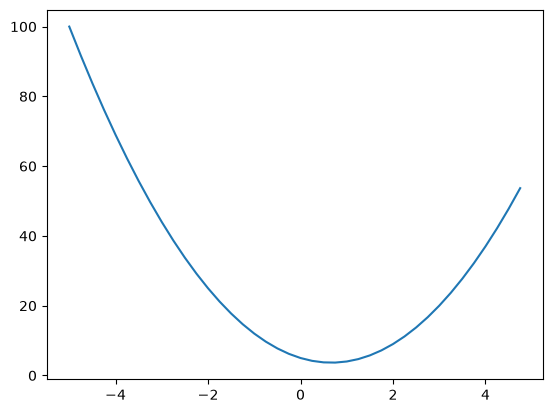

In [5]:
plt.plot(xs, ys)

In [6]:
# the definition of derivates:
# if you slightly change your x value by a small number h (very close to 0), how does the function respond?
# does the function go up? (positive slope / response) or go down? (negative slope / response)

h = 0.001
x = 3.0
f(x+h) # response of function after slight increase. Expect it to be slightly higher since it's increasing there
# by how much? 0.014003000000002 in the positive direction. 

20.014003000000002

In [7]:
# trying converting h -> 0:
h = 0.00000000001

# note: if go too close to 0, errors because there's finite number of precision you could use in computers

# note: 
# normalizing the increase:
(f(x+h) - f(x))/h
# this converges towards 6x - 4, plug 3, get 14 (seems correct)

14.000178794049134

In [8]:
# Expectations at -3: the function would decrease going forward
x = -3.0
(f(x+h) - f(x))/h

-21.999824184604222

In [9]:
# at x=2/3, the derivative is 0 (if we nudge in a positive direction there,
# the function doesn't respond)
x= 2/3
(f(x+h) - f(x))/h

0.0

In [10]:
# let's get more complex:
h = 0.0001

a = 2.0
b = -3.0
c = 10.0

d1 = a*b + c

a += h
d2 = a*b + c

print("d1:", d1)
# before we print off d2, let's visualize wether it will be lesser or greater than d1 in value
# we bump a by h -> a will be slightly positive BUT b is a negative number, therefore we're going to 
# add a more negative number, so the value should go down

print("d2:", d2)
# as expected, 4.0 -> 3.9996

print("slope", (d2-d1)/h) # differentiating d with respect to a basically
# this also makes sense using derivative rules (you're just left with b in the equation)

# same goes with differentiating d1 with respect to b (js a) or c (js 1)

d1: 4.0
d2: 3.999699999999999
slope -3.000000000010772


In [11]:
# The neural networks that we train won't just have one or two terms of doing derivatives 
# (unlike us having just three terms here) - we have thousands upon thousands of terms

# Thus, we would need to build special data structures that hold these terms where we can do derivatives on them quickly

In [12]:
class Value:
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self._prev = set(_children) # who is contributing to this value?
        self._op = _op # what operation created this value?
        self.label = label # label to represent in like visualizing graphs

    def __repr__(self): # python uses __repr__ internally to return a string or something as a representation
        # instead of just showing location in memory
        return f"Value(data={self.data})"

    def __add__(self, other): # special method to define the plus operator for this object:
        # a + b will be a.__add__(b), and b will be passed as other
        out = Value(self.data + other.data, (self, other), '+') # making self and other as prev of this value
        
        return out

    def __mul__(self, other):
        out = Value(self.data * other.data, (self, other), '*')
        return out

a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')

e = a*b; e.label = 'e'
d = a*b + c; d.label = 'd'
f = Value(-2.0, label='f')
L = d * f; L.label = 'L Output'

In [13]:
d._prev

{Value(data=-6.0), Value(data=10.0)}

In [14]:
d._op

'+'


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


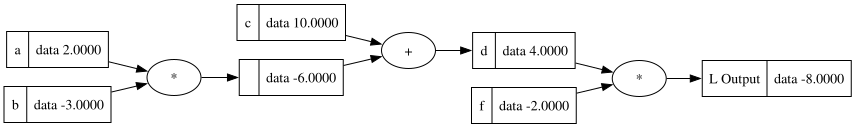

In [15]:
# Since these expressions will become complicated, here is code to visualize it:
# 1. calls a function draw_dot on some root node (value)
# 2. uses graphviz library to build out a visualization

%pip install graphviz
from graphviz import Digraph

def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root, format='svg', rankdir='LR'):
    """
    format: png | svg | ...
    rankdir: TB (top to bottom graph) | LR (left to right)
    """
    assert rankdir in ['LR', 'TB']
    nodes, edges = trace(root)
    dot = Digraph(format=format, graph_attr={'rankdir': rankdir}) #, node_attr={'rankdir': 'TB'})
    
    for n in nodes:
        dot.node(name=str(id(n)), label = "{%s | data %.4f }" % (n.label, n.data), shape='record')
        if n._op:
            dot.node(name=str(id(n)) + n._op, label=n._op)
            dot.edge(str(id(n)) + n._op, str(id(n)))
    
    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    
    return dot

draw_dot(L)

In [16]:
# so far: we have multiple expressions (forward pass) to produce a final value (L here)

# what we would like to do is now to start backpropagation, and calculate the gradients 
# across all the intermediate values (derivative of that node with respect to L)
# therefore, we will store a gradient property in the Value class:

class Value:
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0 # initially, this node doesn't affect the final value (therefore 0 gradient)
        
        self._prev = set(_children) # who is contributing to this value?
        self._op = _op # what operation created this value?
        self.label = label # label to represent in like visualizing graphs

    def __repr__(self): # python uses __repr__ internally to return a string or something as a representation
        # instead of just showing location in memory
        return f"Value(data={self.data})"

    def __add__(self, other): # special method to define the plus operator for this object:
        # a + b will be a.__add__(b), and b will be passed as other
        out = Value(self.data + other.data, (self, other), '+') # making self and other as prev of this value
        
        return out

    def __mul__(self, other):
        out = Value(self.data * other.data, (self, other), '*')
        return out

a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')

e = a*b; e.label = 'e'
d = a*b + c; d.label = 'd'
f = Value(-2.0, label='f')
L = d * f; L.label = 'L Output'

In [17]:
# adjusting draw_dot for new gradient field:
from graphviz import Digraph

def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root, format='svg', rankdir='LR'):
    """
    format: png | svg | ...
    rankdir: TB (top to bottom graph) | LR (left to right)
    """
    assert rankdir in ['LR', 'TB']
    nodes, edges = trace(root)
    dot = Digraph(format=format, graph_attr={'rankdir': rankdir}) #, node_attr={'rankdir': 'TB'})
    
    for n in nodes:
        dot.node(name=str(id(n)), label = "{%s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
        if n._op:
            dot.node(name=str(id(n)) + n._op, label=n._op)
            dot.edge(str(id(n)) + n._op, str(id(n)))
    
    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    
    return dot


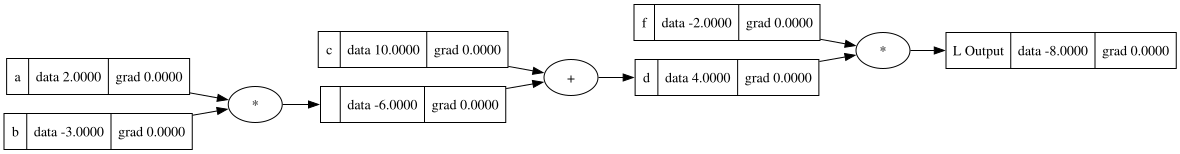

In [18]:
draw_dot(L)

In [19]:
# doing backpropagation manually:
# 1. derivative of L wrt L: always 1 (proportional), so start with L's grad = 1

def manual_backprop():
    h = 0.00001
    
    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a*b; e.label = 'e'
    d = a*b + c; d.label = 'd'
    f = Value(-2.0, label='f')
    L = d * f; L.label = 'L'
    L1 = L.data

    # DERIVATIVE OF A WRT L
    a = Value(2.0 + h, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a*b; e.label = 'e'
    d = a*b + c; d.label = 'd'
    f = Value(-2.0, label='f')
    L = d * f; L.label = 'L'
    L2 = L.data

    print((L2-L1)/h) # it's 6

    # Note: If you do L2 = L.data + h, and take derivative (L2-L1/h), you get 1 (expected)

manual_backprop()

6.000000000128124


In [20]:
# Starting point
L.grad = 1

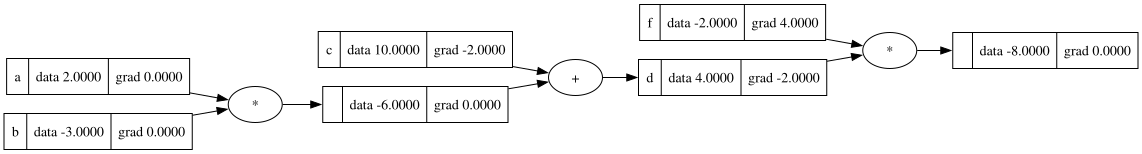

In [21]:
L = d * f

# to find gradient of d, we want DL/Dd = f (we can also derive it by using the definition of derivative
# ((d+h)*f - d*f)/h
f.grad = d.data # which is the same as adding an h in f's equation in the above function manual_backprop() 
d.grad = f.data

# Now, the most important node to understand in our L equation to get the gist of backpropagation:

# we need to derive dL/dc:
# problem: we know how d is sensitive to L, but how do we know how c impacts L?

# in this problem, we know how c impacts d; and we also know how d impacts L -> so can we get to know how c impacts L? Yes!
# Putting those two information together:

# d = c + e
# finding out the LOCAL DERIVATIVE (nodes adjacent to each other):
# dd/dc: 1.0, derivable by the (f(x+h)-f(x)/)h, that is:
# (c + h + e - c - e)/h = h/h = 1.0
# by symmetry, dd/de = 1.0 as well

# what we now want is dL/dc: we use the CHAIN RULE in calculus
#`intuitive explanation:
# if a car travels 2x fast as a bicycle, and a bicycle travels 4x fast as a walking man, a car is 2 x 4 = 8x faster than a walking man
# i.e, dz/dx = dz/dy * dy/dx (general equation)
# i.e. dL/dc = dL/dd * dd/dc = d.grad * local grad. of dc = -2 (f.val) * 1.0 (local grad) = -2
c.grad = -2

# by symmetry, e.grad ALSO -2 (because 1.0 local gradd because of the addition)
e.grad = -2

draw_dot(L)

In [22]:
# next, apply it to a and b:
# reminder: we want one pre-calculated gradient from the layer next to the current node
# as well as a local derivative

# e = a*b
# we know dL/de = -2
# and by calculus, de/da = b = -3
# want dL/da = dL/de * de/da = -2 * -3 = 6.0

# by symmetry, dL/db = -2 * 2 = -4

# Therefore, backpropagation is just recursive application of chain rule backwards through the computation graph